
# This script performs:
1. Load spatial transcriptomics data (axolotl brain regeneration)
2. Preprocess and select highly variable genes
3. Construct spatial graph using AlphaComplex
4. Train StPedf model to obtain low-dimensional embedding
5. Build adaptive transition matrix (embedding + spatial proximity)
6. Infer pseudotime from a user-defined starting region
7. Compute velocity field and vector field
8. Compute least-action path between two spatial points
9. Identify trajectory-associated genes and plot heatmap


In [1]:

# %%
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import ot
from anndata import AnnData
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import collections
import scipy.sparse as sp
# Fix Python 3.10+ compatibility
collections.Iterable = collections.abc.Iterable

# Custom modules
import StPedf
import TI as spt
from TI.single_time import construct_adaptive_transition_matrix

# %%
# Set random seed for reproducibility
random_seed = 2025
StPedf.fix_seed(random_seed)


# 1. Load data and build AnnData

In [2]:
# %%
adata = sc.read("F:/StPedf/data/axolotl brain regeneration afrer injury/D15_4.ST.exp.tsv")
df_annot = pd.read_table("F:/StPedf/data/axolotl brain regeneration afrer injury/D15_4.ST.annot.tsv")

# Add spatial coordinates and cluster labels
adata.obsm["spatial"] = df_annot[["x", "y"]].values  
adata.obs["cluster"] = df_annot["cluster"].values

Only considering the two last: ['.exp', '.tsv'].
Only considering the two last: ['.exp', '.tsv'].


#  2. Preprocessing

In [3]:
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['count'] = adata.X.copy()

# Highly variable genes
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable']]

# PCA
sc.pp.pca(adata, n_comps=100)

# 3. Visualize spatial clusters

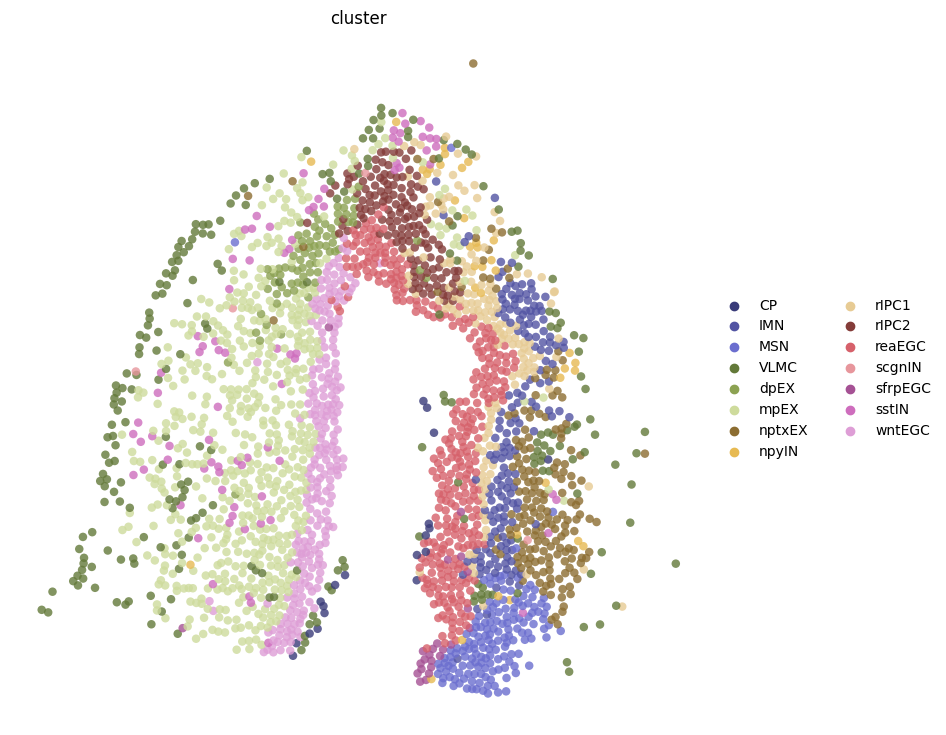

In [4]:
fig, ax = plt.subplots(figsize=(9, 9))
sc.pl.embedding(adata, basis='spatial', color='cluster', show=False, ax=ax,
                frameon=False, palette='tab20b', alpha=0.8, size=150)
plt.show()



# 4. Construct spatial graph (AlphaComplex)

In [5]:
graph_dict = StPedf.graph_construction(
    adata, 
    12,
    mode='AlphaComplex', 
    alpha_n_neighbors=15  
)
print("Graph keys:", list(graph_dict.keys()))

Graph keys: ['adj_norm', 'adj_label', 'norm_value']


# 5. Train StPedf model

In [6]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

StPedf_net = StPedf.StPedf(
    adata.obsm['X_pca'], 
    graph_dict, 
    mode='clustering',
    device=device
)

# Train with deep embedding clustering
using_dec = True
n_epochs = 200
if using_dec:
    StPedf_net.train_with_dec(N=n_epochs)
    StPedf_feat, _, _, _, _ = StPedf_net.process()
    adata.obsm['StPedf'] = StPedf_feat


100%|██████████| 200/200 [00:02<00:00, 88.26it/s]


# 6. Build adaptive transition matrix

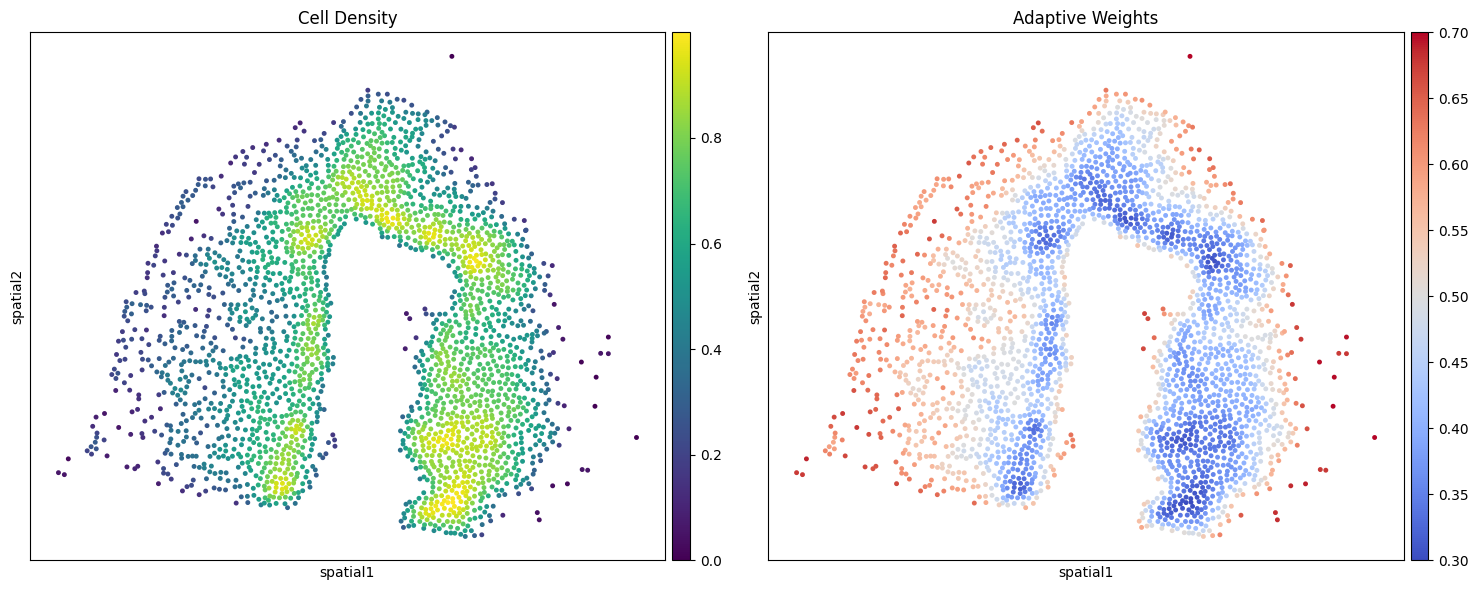

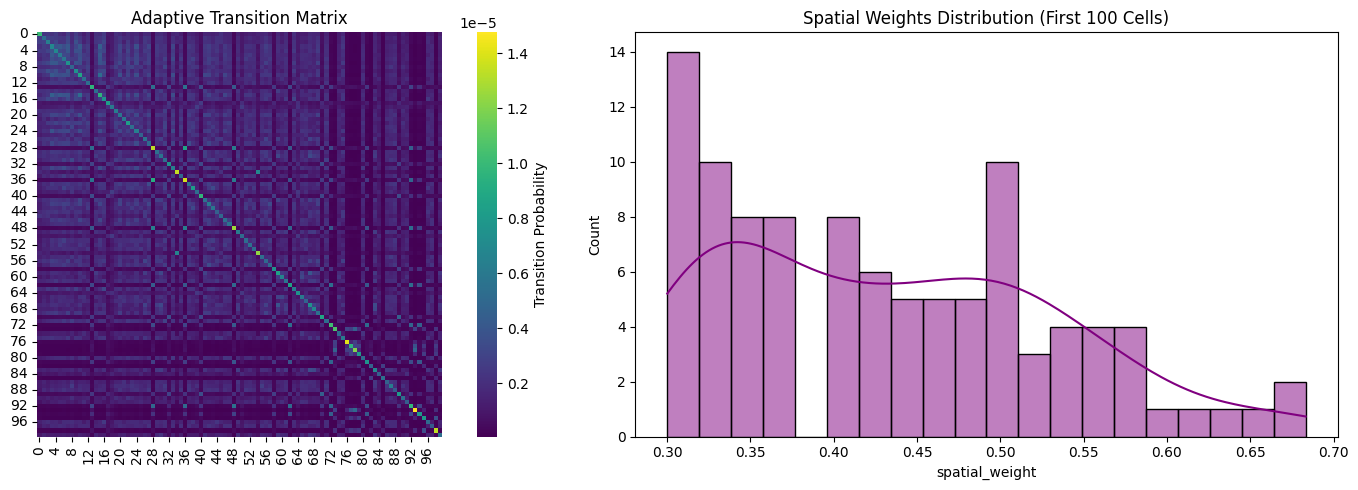

In [7]:
trans = construct_adaptive_transition_matrix(
    adata,
    StPedf_key='StPedf',
    spatial_key='spatial',
    reg=0.1,          # Sinkhorn regularization
    base_alpha=0.5,
    alpha_range=(0.3, 0.7),
    spot_size=50
)
adata.obsp["adaptive_trans"] = trans

# Visualize transition matrix and spatial weights
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(trans[:100, :100], cmap='viridis', square=True, ax=ax1,
            cbar_kws={'label': 'Transition Probability'})
ax1.set_title("Adaptive Transition Matrix")
sns.histplot(adata.obs['spatial_weight'].iloc[:100], bins=20, kde=True, ax=ax2, color='purple')
ax2.set_title("Spatial Weights Distribution (First 100 Cells)")
plt.tight_layout()
plt.show()

# 7. Pseudotime inference from a starting region

Number of start cells: 26


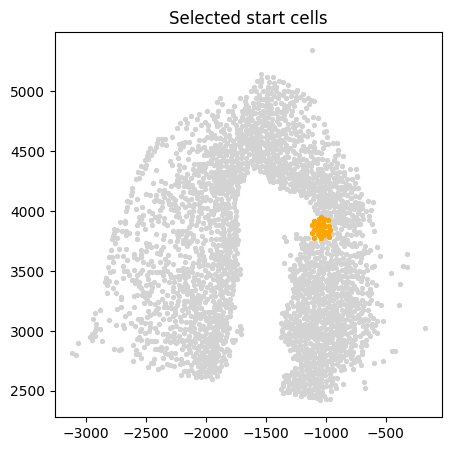

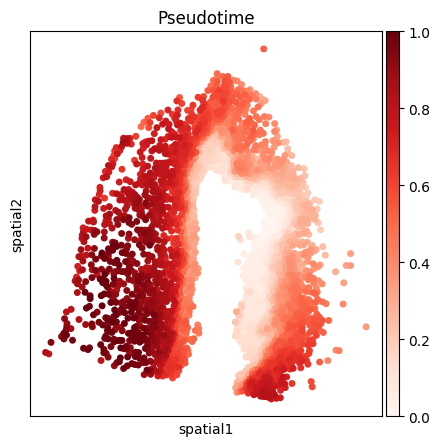

In [8]:
adata.obsm['X_spatial'] = adata.obsm['spatial']

# Select starting cells near a given coordinate
start_point = [-1050, 3850]
start_cells = spt.set_start_cells(
    adata,
    select_way='coordinates',
    cell_type='reaEGC',      # this parameter is ignored when select_way='coordinates'
    start_point=start_point,
    n_neigh=30
)
start_cells = np.array(start_cells).flatten()
print(f"Number of start cells: {len(start_cells)}")


# Visualize start cells
plt.figure(figsize=(5, 5))
plt.scatter(adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1], c='#D3D3D3', s=8)
plt.scatter(adata.obsm['spatial'][start_cells, 0], adata.obsm['spatial'][start_cells, 1], c='orange', s=8)
plt.title("Selected start cells")
plt.show()

# Compute pseudotime
adata.obsp["trans"] = adata.obsp["adaptive_trans"]  
adata.obs["ptime"] = spt.get_ptime(adata, start_cells=start_cells)

# Visualize pseudotime on spatial map
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.embedding(adata, basis='spatial', color='ptime', show=False, ax=ax,
                color_map='Reds', title='Pseudotime', size=100)
plt.show()

# 8. Compute velocity field

Cell velocities stored in 'velocity_spatial'


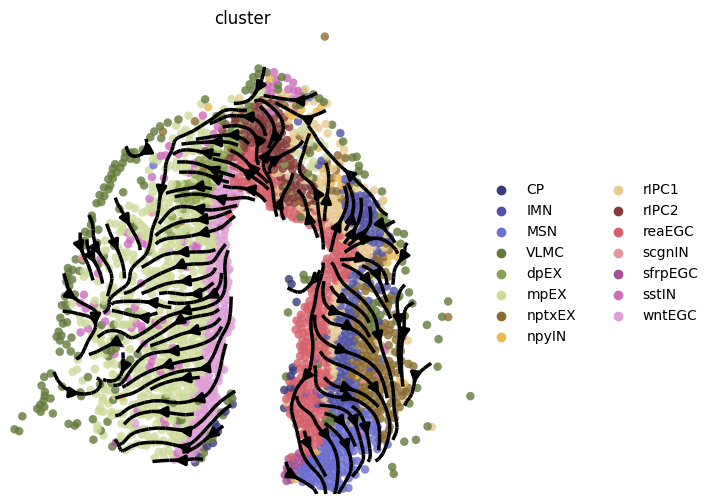

In [9]:
adata.uns["E_grid"], adata.uns["V_grid"] = spt.get_velocity(adata, basis="spatial", n_neigh_pos=50)

VecFld = spt.VectorField(
    adata,
    basis='spatial',
    velocity_key='velocity_spatial',
    n_neighbors=80,
    smooth=1.2
)

# Plot streamlines
fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.embedding(adata, basis='spatial', color='cluster', show=False, ax=ax,
                frameon=False, palette='tab20b', alpha=0.8, size=150)
ax.streamplot(adata.uns['E_grid'][0], adata.uns['E_grid'][1],
              adata.uns['V_grid'][0], adata.uns['V_grid'][1],
              density=1.8, color='black', linewidth=2.5, arrowsize=1.5)
plt.show()

# 9. Least-action path between two points

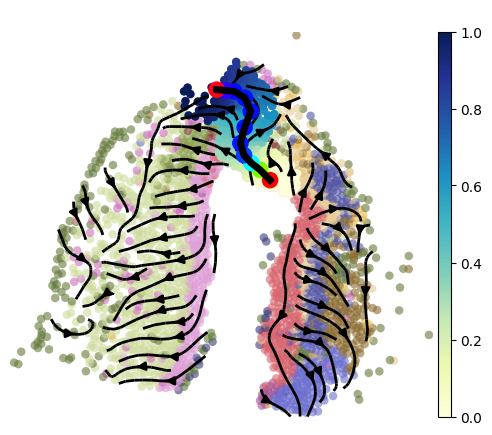

In [10]:
if not sp.issparse(adata.obsp["trans"]):
    adata.obsp["trans"] = sp.csr_matrix(adata.obsp["trans"])
# %%
LAP_start_point = [-1300, 4250]
LAP_end_point   = [-1700, 5000]
LAP_start_cell = spt.nearest_neighbors(LAP_start_point, adata.obsm['spatial'])[0][0]
LAP_end_cell   = spt.nearest_neighbors(LAP_end_point, adata.obsm['spatial'])[0][0]

# Compute least-action path
lap = spt.least_action(
    adata,
    init_cells=[adata.obs_names[LAP_start_cell]],
    target_cells=[adata.obs_names[LAP_end_cell]],
    vecfld=VecFld,
    basis="spatial",
    adj_key="trans",      # use the transition matrix
    EM_steps=5,
    n_points=20
)

# Map cells to the path and extract sub-adata along path
LAP_ptime, LAP_nbrs = spt.map_cell_to_LAP(adata, cell_neighbors=80)
sub_adata = adata[LAP_nbrs, :].copy()
sub_adata.obs['ptime'] = LAP_ptime
sub_adata = sub_adata[np.argsort(sub_adata.obs["ptime"].values), :]

# Plot path with pseudotime coloring
fig, ax = plt.subplots(figsize=(6, 5))
plt.axis('off')
sc.pl.embedding(adata, basis='spatial', color='cluster', show=False, ax=ax,
                frameon=False, legend_loc=None, alpha=0.6, size=150)
ax.streamplot(adata.uns['E_grid'][0], adata.uns['E_grid'][1],
              adata.uns['V_grid'][0], adata.uns['V_grid'][1],
              density=1.2, color='black', linewidth=2, arrowsize=1.2)
spt.plot_least_action_path(adata, basis='spatial', ax=ax, point_size=120, linewidth=5)
sc.pl.embedding(sub_adata, basis='spatial', ax=ax, color="ptime",
                cmap="YlGnBu", frameon=True, size=150, title=' ')
plt.show()

# 10. Identify trajectory-associated genes

clusters ordered by ptime:  ['reaEGC', 'rIPC2', 'dpEX', 'IMN']
Cell number	219
Gene number	383
Genes number fitted by GAM model:   383
Finally selected 48 genes.


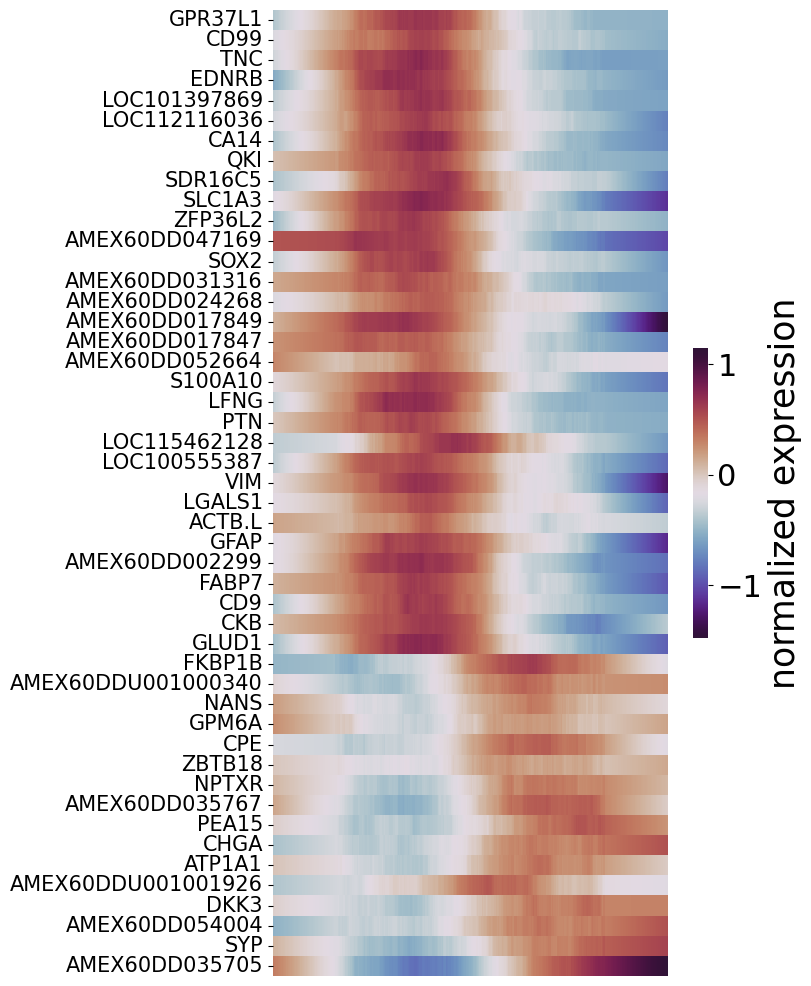

In [11]:
# Subset to specific cell types along the trajectory
sub_adata_path = sub_adata[sub_adata.obs['cluster'].isin(['reaEGC', 'rIPC2', 'IMN', 'dpEX'])]
sub_adata_path = spt.filter_gene(sub_adata_path, min_exp_prop=0.1, hvg_gene=3000)

# Fit GAM to find genes that vary with pseudotime
df_res = spt.ptime_gene_GAM(sub_adata_path, core_number=5)
df_sig_res = df_res.loc[(df_res['model_fit'] > 0.2) & (df_res['fdr'] < 0.05)]

# Order genes and plot heatmap
sort_exp_sig = spt.order_trajectory_genes(sub_adata, df_sig_res, cell_number=20)
spt.plot_trajectory_gene_heatmap(sort_exp_sig, smooth_length=100,
                                 gene_label_size=15, cmap_name='twilight_shifted')
plt.show()